In [6]:
import argparse
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import torch.nn.functional as F
import powerlaw
import json
import seaborn as sns

from tqdm import tqdm
from torch.utils.data import DataLoader
from models.resnet import *
from torch.nn.utils import parameters_to_vector
import csv

from src.pyhessian.hessian import hessian
from src.visualize import *
from utils import *

In [7]:
results = []

with open("./results/results.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        if line.strip():  
            results.append(json.loads(line))

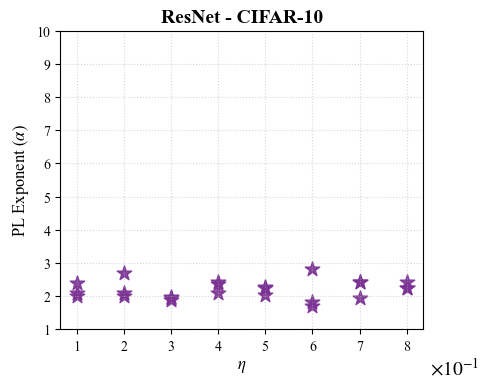

In [8]:
x = []
y = []

for result in results:
    x.append(result["lr"])
    y.append(result["alpha"])

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['mathtext.fontset'] = 'stix'

plt.subplots(figsize=(5, 4))

plt.scatter(x, y, marker='*', s=120, color='#7b3294', alpha=0.9)

plt.xlabel(r'$\eta$', fontsize=12)
plt.ylabel(r'PL Exponent ($\alpha$)', fontsize=12)
plt.title(r'ResNet - CIFAR-10', fontsize=14, fontweight='bold')

plt.ylim(1.0, 10.0)

plt.ticklabel_format(style='sci', axis='x', scilimits=(-1, -1), useOffset=False)
plt.gca().xaxis.get_offset_text().set_visible(False)

plt.text(
    1.02, -0.15,
    r'$\times 10^{-1}$',
    transform=plt.gca().transAxes,
    fontsize=14
)

plt.grid(True, linestyle=':', alpha=0.5)

save_path = os.path.join("./visualization", "alpha_vs_lr_cnn.pdf")
os.makedirs("./visualization", exist_ok=True)

plt.tight_layout()
plt.savefig(save_path)
plt.show()

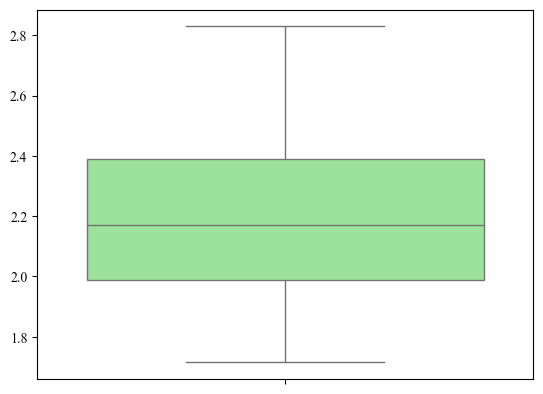

In [9]:
sns.boxplot(
    y=y,
    color='lightgreen',
    fliersize=6
)

plt.savefig("./visualization/box_plot.pdf")
plt.show()